# Compare Spatiotemporal Linear Reconstructions for Visually Evoked vs Electrically Evoked Responses

In [1]:
%reload_ext autoreload
%autoreload 2

# Imports
import numpy as np
import visionloader as vl
import rawmovie
import matplotlib.pyplot as plt
import os
import scipy as sp
from tqdm import tqdm
import torch

In [2]:
# Modifed from ARG lnp.py functions

def get_frame_times(ttl_times,frames_per_ttl):
    """
    Linearly interpolates frame times based on the ttls

    Parameters:
        ttl_times: ttl times
        frames_per_ttl: frames per ttl
    
    Returns:
        Array of interpolated frame times.
    """

    frame_times = []

    for i in range(ttl_times.shape[0]-1):
        frame_times.append(np.linspace(ttl_times[i],
                               ttl_times[i+1],
                               frames_per_ttl,
                               endpoint=False))

    return np.asarray(frame_times).ravel()

def get_binned_spikes(vcd,cells):
    '''
    Parameters:
        vcd: Vision data table object
        cells: list of cells to compute STAs for
    Returns:
        A matrix of size frames by cells

    Bins the spike train using the (full resolution) frames of the monitor 
    as bin edges.
    '''
    frames_per_ttl = 60 # SUBJECT TO CHANGE

    # Get the interpolated frame times.
    ttl_times = vcd.ttl_times[30:30+100] / 20000 * 1000 # ms # SUBJECT TO CHANGE
    
    frame_times = get_frame_times(ttl_times,frames_per_ttl)

    # Set the bin edges as as the frame times with an additional fake frame.
    monitor_interval = 1 / 120 * 1000
    bin_edges = np.append(frame_times,frame_times[-1] +  monitor_interval)

    # Loop through cells and bin spike train.
    binned_spikes = []

    for cell in cells:
        spike_times = vcd.get_spike_times_for_cell(cell) / 20000 * 1000 # ms
        binned_spikes.append(np.histogram(spike_times,bins=bin_edges)[0])
    
    return np.asarray(binned_spikes).T

Paths

In [3]:
piece = '2024-08-20-0'
analysis_base = f"/Volumes/Stream/Analysis/RETINA/{piece}"
label = ""

In [4]:
# The dictionary and associated data is stored in this directory
# Much of the data/analysis associated with the experiment exists in the parent directory
dict_path = os.path.join(analysis_base, "dictionary")

# Load relevant data from .npz files
with np.load(os.path.join(dict_path,f"selective_stimuli{label}.npz")) as data:
    selective_stimuli = data["selective_stimuli"]

selective_cells_of_interest = np.unique(selective_stimuli[:,1]).astype(int)
print(f"Total selective cells: {selective_cells_of_interest.size}")

Total selective cells: 25


In [15]:
vstim_base = analysis_base
vstim = "data005_from_data002"
vstim_path = os.path.join(vstim_base, vstim)

vstim_vcd1 = vl.load_vision_data(vstim_path,vstim,
                                include_neurons=True)

binned_spikes1 = get_binned_spikes(vstim_vcd1,selective_cells_of_interest)
print(binned_spikes1.shape)

(149820, 25)


In [16]:
N = 30 # temporal dimension of reconstruction filter
M1 = binned_spikes1.shape[0] - N + 1
R1 = np.zeros((M1, 1 + N * binned_spikes1.shape[1]), dtype=np.uint8)
for i in range(M1):
    R1[i,0] = 1
    R1[i,1:] = binned_spikes1[i:i+N].ravel(order='F') # column-major order
print(R1.shape)

(149791, 751)


In [17]:
imagenet1 = rawmovie.RawMovieReader(f"/Volumes/Data/Stimuli/imagenet/INbrownian/INbrownian_05s_2500_0A_045.rawMovie")
imagenet_frames1, _ = imagenet1.get_frame_sequence(0,2498*60) 
imagenet_frames1 = imagenet_frames1[:,:,:,0] # All color channels are the same
num_frames1, pixels_y1, pixels_x1 = imagenet_frames1.shape
S1 = imagenet_frames1.reshape((num_frames1,-1))[:M1]
print(S1.shape)

(149791, 51200)


In [18]:
R1_memmap = np.memmap('/Volumes/Stream/Data/tmp/R1_memmap.dat', dtype='uint8', mode='w+', shape=R1.shape)
R1_memmap[:] = R1[:]

# Save R1 shape
np.save('/Volumes/Stream/Data/tmp/R1_shape.npy', R1.shape)

In [20]:
S1_memmap = np.memmap('/Volumes/Stream/Data/tmp/S1_memmap.dat', dtype='uint8', mode='w+', shape=S1.shape)
S1_memmap[:] = S1[:]

# Save S1 shape
np.save('/Volumes/Stream/Data/tmp/S1_shape.npy', S1.shape)

In [21]:
del R1, S1

In [22]:
vstim_base = analysis_base
vstim = "data006_from_data002"
vstim_path = os.path.join(vstim_base, vstim)

vstim_vcd2 = vl.load_vision_data(vstim_path,vstim,
                                include_neurons=True)

binned_spikes2 = get_binned_spikes(vstim_vcd2,selective_cells_of_interest)
print(binned_spikes2.shape)

(149880, 25)


In [23]:
M2 = binned_spikes2.shape[0] - N + 1
R2 = np.zeros((M2, 1 + N * binned_spikes2.shape[1]), dtype=np.uint8)
for i in range(M2):
    R2[i,0] = 1
    R2[i,1:] = binned_spikes2[i:i+N].ravel(order='F') # column-major order
print(R2.shape)

(149851, 751)


In [24]:
imagenet2 = rawmovie.RawMovieReader(f"/Volumes/Data/Stimuli/imagenet/INbrownian/INbrownian_05s_2500_0B_045.rawMovie")
imagenet_frames2, _ = imagenet2.get_frame_sequence(0,2499*60) 
imagenet_frames2 = imagenet_frames2[:,:,:,0] # All color channels are the same
num_frames2, pixels_y2, pixels_x2 = imagenet_frames2.shape
S2 = imagenet_frames2.reshape((num_frames2,-1))[:M2]
print(S2.shape)

(149851, 51200)


In [25]:
R2_memmap = np.memmap('/Volumes/Stream/Data/tmp/R2_memmap.dat', dtype='uint8', mode='w+', shape=R2.shape)
R2_memmap[:] = R2[:]

# Save R2 shape
np.save('/Volumes/Stream/Data/tmp/R2_shape.npy', R2.shape)

In [26]:
S2_memmap = np.memmap('/Volumes/Stream/Data/tmp/S2_memmap.dat', dtype='uint8', mode='w+', shape=S2.shape)
S2_memmap[:] = S2[:]

# Save S2 shape
np.save('/Volumes/Stream/Data/tmp/S2_shape.npy', S2.shape)

In [28]:
del S2, R2

In [2]:
S1_memmap = np.memmap('/Volumes/Stream/Data/tmp/S1_memmap.dat', dtype='uint8', mode='r', shape=tuple(np.load('/Volumes/Stream/Data/tmp/S1_shape.npy')))
R1_memmap = np.memmap('/Volumes/Stream/Data/tmp/R1_memmap.dat', dtype='uint8', mode='r', shape=tuple(np.load('/Volumes/Stream/Data/tmp/R1_shape.npy')))

S2_memmap = np.memmap('/Volumes/Stream/Data/tmp/S2_memmap.dat', dtype='uint8', mode='r', shape=tuple(np.load('/Volumes/Stream/Data/tmp/S2_shape.npy')))
R2_memmap = np.memmap('/Volumes/Stream/Data/tmp/R2_memmap.dat', dtype='uint8', mode='r', shape=tuple(np.load('/Volumes/Stream/Data/tmp/R2_shape.npy')))

In [3]:
S_train = np.concatenate((S1_memmap, S2_memmap), axis=0)
R_train = np.concatenate((R1_memmap, R2_memmap), axis=0)

In [3]:
S_train = S1_memmap
R_train = R1_memmap

In [4]:
print(S_train.shape, R_train.shape)

(149791, 51200) (149791, 751)


In [5]:
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
# Compute the linear least squares solution
S_train_gpu = torch.tensor(S_train, dtype=torch.float32, device=device)
R_train_gpu = torch.tensor(R_train, dtype=torch.float32, device=device)

In [7]:
print(S_train_gpu.nbytes, R_train_gpu.nbytes)

30677196800 449972164


In [ ]:
f = torch.matmul(torch.linalg.inv(torch.matmul(R_train_gpu.T, R_train_gpu)), torch.matmul(R_train_gpu.T, S_train_gpu))

In [16]:
chunk_size = 10000
for i in tqdm(range(0, S_train.shape[0], chunk_size)):
    if i + chunk_size > S_train.shape[0]:
        continue

    # Compute rTr and rTs on GPU
    rTr = torch.matmul(torch.from_numpy(R_train[i:i+chunk_size].T), torch.from_numpy(R_train[i:i+chunk_size]))
    rTs = torch.matmul(torch.from_numpy(R_train[i:i+chunk_size].T), torch.from_numpy(S_train[i:i+chunk_size]))

    # Save rTr and rTs to disk
    torch.save(rTr, f'/Volumes/Stream/Data/tmp/intermediate/rTr_{i}.pt')
    torch.save(rTs, f'/Volumes/Stream/Data/tmp/intermediate/rTs_{i}.pt')

100%|██████████| 30/30 [15:52<00:00, 31.76s/it]


In [18]:
# Read rTr and rTs from disk and sum them up
rTr = torch.zeros(R_train.shape[1], R_train.shape[1])
rTs = torch.zeros(R_train.shape[1], S_train.shape[1])
for i in tqdm(range(0, S_train.shape[0], chunk_size)):
    if i + chunk_size > S_train.shape[0]:
        continue

    rTr += torch.load(f'/Volumes/Stream/Data/tmp/intermediate/rTr_{i}.pt', weights_only=True)
    rTs += torch.load(f'/Volumes/Stream/Data/tmp/intermediate/rTs_{i}.pt', weights_only=True)

100%|██████████| 30/30 [00:01<00:00, 18.77it/s]


In [19]:
# Check that rTr is full rank
print(torch.linalg.matrix_rank(rTr) == np.min(rTr.shape))

tensor(False)


In [20]:
# Compute the linear least squares solution
f = torch.matmul(torch.linalg.inv(rTr), rTs)

In [24]:
# Save the linear least squares solution as numpy array to disk
np.save('/Volumes/Stream/Data/tmp/lstsq.npy', f.detach().cpu().numpy())

In [5]:
# Load the linear least squares solution from disk as numpy array
lstsq = np.load('/Volumes/Stream/Data/tmp/lstsq.npy')
print(lstsq.shape)

(751, 51200)


In [6]:
vstim_base = analysis_base
vstim = "data004_from_data002"
vstim_path = os.path.join(vstim_base, vstim)

vstim_vcd = vl.load_vision_data(vstim_path,vstim,
                                include_neurons=True)

binned_spikes = get_binned_spikes(vstim_vcd,selective_cells_of_interest)
print(binned_spikes.shape)

(5940, 25)


In [7]:
N = 30 # temporal dimension of reconstruction filter
M = binned_spikes.shape[0] - N + 1
R = np.zeros((M, 1 + N * binned_spikes.shape[1]), dtype=np.uint8)
for i in range(M):
    R[i,0] = 1
    R[i,1:] = binned_spikes[i:i+N].ravel(order='F') # column-major order
print(R.shape)

(5911, 751)


In [8]:
imagenet = rawmovie.RawMovieReader(f"/Volumes/Data/Stimuli/imagenet/INbrownian/INbrownian_05s_test_045.rawMovie")
imagenet_frames, _ = imagenet.get_frame_sequence(0,100*60) 
imagenet_frames = imagenet_frames[:,:,:,0] # All color channels are the same
num_frames, pixels_y, pixels_x = imagenet_frames.shape
S = imagenet_frames.reshape((num_frames,-1))[:M]
print(S.shape)

(5911, 51200)


In [9]:
reconstructions = R @ lstsq

In [10]:
print(reconstructions.shape)

(5911, 51200)


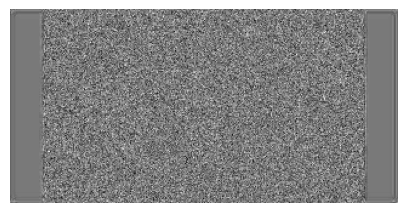

In [14]:
# Visualize reconstruction filters
filter_index = 1 + 46

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(lstsq[filter_index].reshape(pixels_y, pixels_x), cmap='gray')
ax.axis('off')
plt.show()

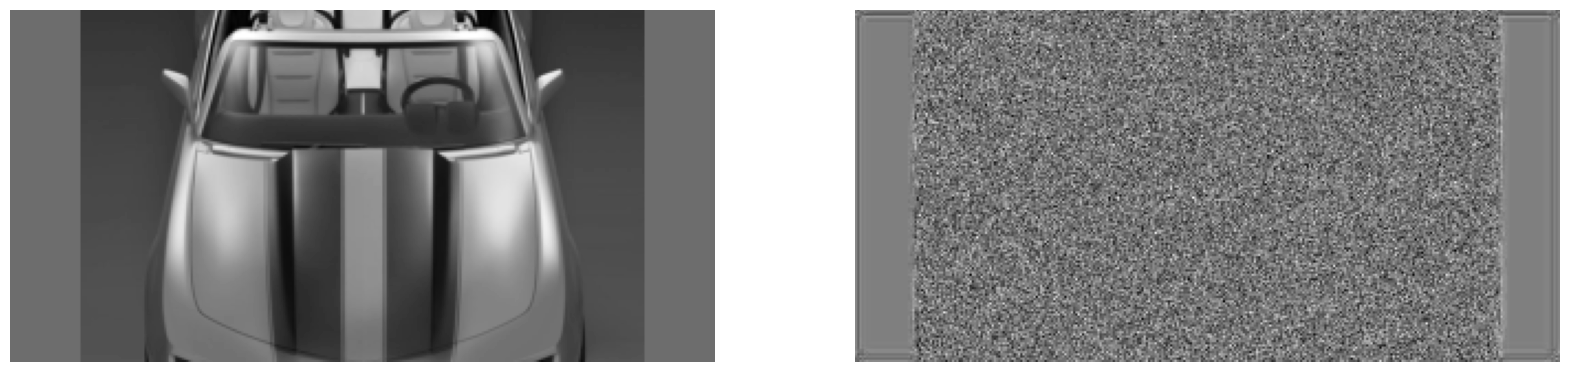

In [31]:
img_index = 2 * 60

fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(imagenet_frames[img_index].reshape(pixels_y,pixels_x), cmap='gray')
ax[0].axis('off')
ax[1].imshow(reconstructions[img_index].reshape(pixels_y,pixels_x), cmap='gray')
ax[1].axis('off')
plt.show()